## STEP 1: Exploratory Data Analysis:


### Import libraries:

In [31]:
import os
import pandas as pd
import numpy as np 

import json
import cv2
import matplotlib as plt

from PIL import Image

### Load data

In [32]:
print(os.listdir("../data"))

splits = ["train","val","test"]
    

['instances_val2019.json', 'test2019', 'train2019', 'val2019', 'instances_test2019.json', 'instances_train2019.json']


In [33]:
# Now create a variable to store each path

paths = {} #empty dictionary to store paths

for split in splits:
    #Directory PATH:
    paths[f"{split}_path"] = os.path.join('../data/', f"{split}2019")

    #JSON PATHS
    paths[f"{split}_json"] = os.path.join('../data/',f"instances_{split}2019")

#print the dictionary:
print(paths)

{'train_path': '../data/train2019', 'train_json': '../data/instances_train2019', 'val_path': '../data/val2019', 'val_json': '../data/instances_val2019', 'test_path': '../data/test2019', 'test_json': '../data/instances_test2019'}


In [34]:
import os

splits = ["train", "val", "test"]
data_root = "../data"
data_map = {}

for split in splits:
    #sub-dictionary for every split
    data_map[split] = {
        "images": os.path.join(data_root, f"{split}2019"),
        "annotations": os.path.join(data_root, f"instances_{split}2019.json")
    }

# --- Verification Loop ---
for split, info in data_map.items():
    print("-" * 30)
    print(f"Checking Split: {split.upper()}")
    
    img_dir = info["images"]
    ann_file = info["annotations"]

    if os.path.exists(img_dir) and os.path.exists(ann_file):
        num_files = len(os.listdir(img_dir))
        print(f"  [OK] Images Path: {img_dir} ({num_files} files found)")
        print(f"  [OK] JSON Path:   {ann_file}")
    else:
        print(f"  [ERROR] Path mismatch for {split}!")
    print()

------------------------------
Checking Split: TRAIN
  [OK] Images Path: ../data/train2019 (53739 files found)
  [OK] JSON Path:   ../data/instances_train2019.json

------------------------------
Checking Split: VAL
  [OK] Images Path: ../data/val2019 (6000 files found)
  [OK] JSON Path:   ../data/instances_val2019.json

------------------------------
Checking Split: TEST
  [OK] Images Path: ../data/test2019 (24000 files found)
  [OK] JSON Path:   ../data/instances_test2019.json



In [35]:
#Unpack the paths and store them in clear variables for later use:

train_img = data_map["train"]["images"]
train_json = data_map["train"]["annotations"]

val_img = data_map["val"]["images"]
val_json = data_map["val"]["annotations"]

test_img = data_map['test']['images']
test_json = data_map['test']['annotations']

### Explore JSON Files:

In [36]:
#Explore the JSON structure

#Open json file (instance_train.json in this example):
with open(train_json, 'r') as f:
    data = json.load(f)


print(data.keys(), '\n')

if 'images' in data:
    print(f"First Image entries: {data['images'][0]}")

if 'categories' in data:
    print(f"First categories: {data['categories'][0]}")

if 'annotations' in data:   
    print(f"Fisrt annotations entry: {data['annotations'][0]}")

dict_keys(['info', 'licenses', 'categories', '__raw_Chinese_name_df', 'images', 'annotations']) 

First Image entries: {'file_name': '038900004095_camera0-13.jpg', 'width': 2592, 'height': 1944, 'id': 0}
First categories: {'supercategory': 'puffed_food', 'id': 1, 'name': '1_puffed_food'}
Fisrt annotations entry: {'area': 111763.29, 'bbox': [1188.4, 1052.45, 390.96, 285.87], 'category_id': 112, 'id': 0, 'image_id': 0, 'iscrowd': 0, 'segmentation': [[]], 'point_xy': [1383.88, 1195.38]}


In [37]:
#Create a unified dictionary to link each [id] with its corresponding [category]

supercategory_id_to_name = {category['id']:category['supercategory'] for category in data['categories']}
category_id_to_name =  {category['id']:category['name'] for category in data['categories']}

#Confirm the number of categories (should be 200)
print(f"Total number of categories: {len(supercategory_id_to_name)}")
print(f"toatl number of sub_categories: {len(category_id_to_name)}")

print(f"\n Sample category ID: {supercategory_id_to_name.get(8)}")
print(f"Sample category ID: {category_id_to_name.get(8)}")

Total number of categories: 200
toatl number of sub_categories: 200

 Sample category ID: puffed_food
Sample category ID: 8_puffed_food


In [70]:
#pick random images (to not always pick the first one):

import random
random_img = random.choice(data['images'])
img_id = random_img['id']
file_name = random_img['file_name']

#get image annotation:
img_ann = [ann for ann in data['annotations'] if ann['image_id'] == img_id]

#print the random image chosen (you should get a random image everytime)

print(random_img) 
print(f"Image ID: {img_id}")
print(f"File Name: {file_name}")

print(f"Number of annotations for this image: {len(img_ann)}")

#get the img category / supercategoroy:
#first get the category_id from the annotation (assuming one or more category per image)
for ann in img_ann:
    category_id = ann['category_id']
    img_category = category_id_to_name.get(category_id)
    img_supercategory = supercategory_id_to_name.get(category_id)

    print(f"\nAnnotation ID: {ann['id']}") #should match the Image ID !!
    print(f"Image Supercategory: {img_supercategory}")
    print(f"Image Category: {img_category}")
    


{'file_name': '6901844710114_camera3-38.jpg', 'width': 2592, 'height': 1944, 'id': 2870}
Image ID: 2870
File Name: 6901844710114_camera3-38.jpg
Number of annotations for this image: 1

Annotation ID: 2870
Image Supercategory: seasoner
Image Category: 158_seasoner


### Disiplay Some Images with their bounding Boxes

--------------------------------------------------
Split: TRAIN
Split Path:                     ../data/train2019
Random image from train split:    6926475206263_camera0-29.jpg
Full path to random image:      ../data/train2019/6926475206263_camera0-29.jpg
{'file_name': '038900004095_camera0-13.jpg', 'width': 2592, 'height': 1944, 'id': 0}
--------------------------------------------------
Split: VAL
Split Path:                     ../data/val2019
Random image from val split:    20181018-10-06-01-2306.jpg
Full path to random image:      ../data/val2019/20181018-10-06-01-2306.jpg
{'file_name': '20180827-16-07-06-756.jpg', 'width': 1850, 'height': 1850, 'id': 220, 'level': 'easy'}
--------------------------------------------------
Split: TEST
Split Path:                     ../data/test2019
Random image from test split:    20181008-14-36-13-2774.jpg
Full path to random image:      ../data/test2019/20181008-14-36-13-2774.jpg
{'file_name': '20180824-15-44-39-474.jpg', 'width': 1831, 'height

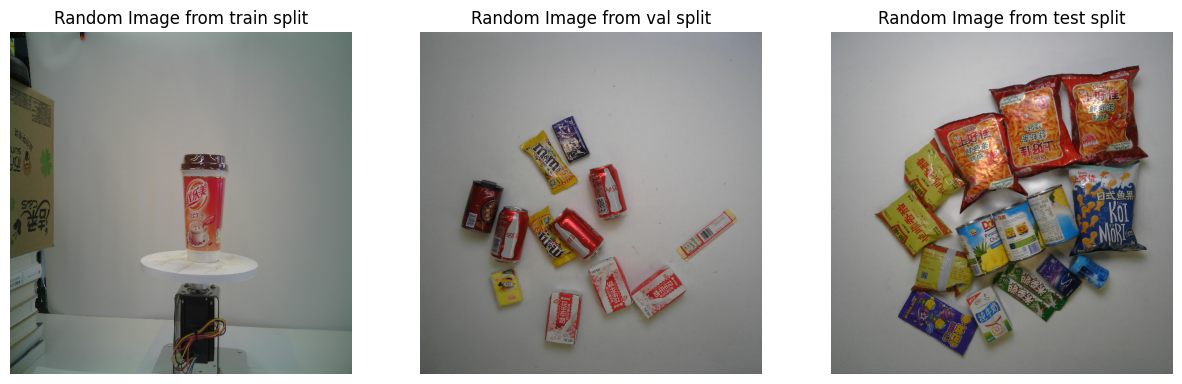

In [139]:
import matplotlib.pyplot as plt
import cv2
import os

#print one image from each split to confirm the paths:

plt.figure(figsize=(15,5))
for i , split in enumerate(splits):
    img_dir = data_map[split]["images"]
    random_img_name = random.choice(os.listdir(img_dir))

    #print the full path:    
    print("-" * 50)
    print(f"Split: {split.upper()}")
    print(f"Split Path:                     {img_dir}")
    print(f"Random image from {split} split:    {random_img_name}")
    print(f"Full path to random image:      {os.path.join(img_dir, random_img_name)}")

    #open the image using cv2:
    img_path = os.path.join(img_dir,random_img_name)
    img = cv2.imread(img_path)

    #convert the image to RGB for displaying:
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(rgb_img, (640,640)) #resize the image to 640x640 for better visualization


    #draw the bounding boxes on the image using the annotation file:
    with open(data_map[split]["annotations"], 'r') as f:
        data = json.load(f)

        print(data['images'][0])
       
        

    #display the image using matplotlib:
    #plot all the images next to each other using subplots:
    plt.subplot(1,3,i+1)
    
    plt.imshow(img_resized)
    plt.title(f"Random Image from {split} split")
    plt.axis('off')
    

plt.show()

--------------------------------------------------
dict_keys(['info', 'licenses', 'categories', '__raw_Chinese_name_df', 'images', 'annotations'])
Random image info: {'file_name': '6920354808388-back_camera0-9.jpg', 'width': 2592, 'height': 1944, 'id': 20824}
--------------------------------------------------
dict_keys(['info', 'licenses', 'categories', '__raw_Chinese_name_df', 'images', 'annotations'])
Random image info: {'file_name': '20181019-17-04-47-2511.jpg', 'width': 1824, 'height': 1824, 'id': 15419, 'level': 'medium'}
--------------------------------------------------
dict_keys(['info', 'licenses', 'categories', '__raw_Chinese_name_df', 'images', 'annotations'])
Random image info: {'file_name': '20181015-14-04-22-1670.jpg', 'width': 1839, 'height': 1839, 'id': 18523, 'level': 'medium'}


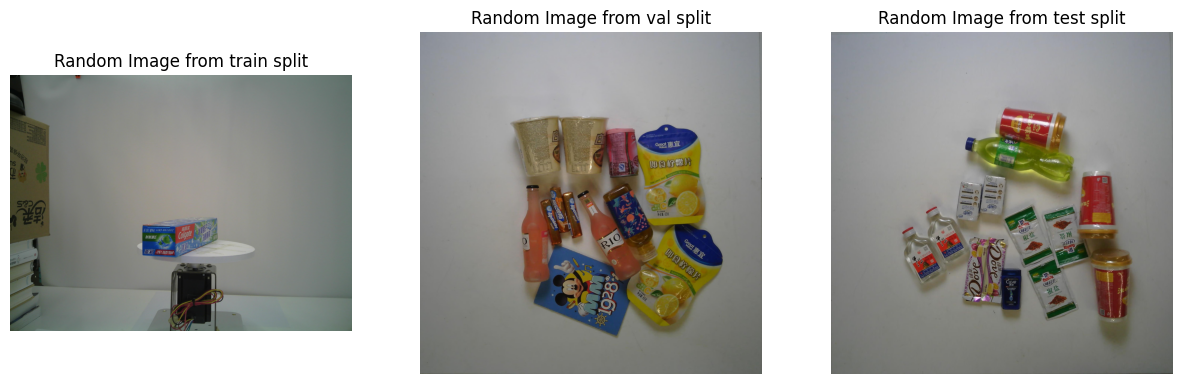

In [153]:
import matplotlib.pyplot as plt
import cv2
import os

#print one image from each split to confirm the paths:

plt.figure(figsize=(15,5))
for i , split in enumerate(splits):

    print("-" * 50)
    #pick the random image form the json file instead of the directory:
    with open(data_map[split]["annotations"], 'r') as f:
        data = json.load(f)
        
        print(data.keys())                              #Check the keys to confirm the structure of the JSON file
        random_img_info = random.choice(data['images']) #Pick the ranodm image from the JSON file

        print(f"Random image info: {random_img_info}") #print the random image info to confirm the structure of the JSON file

        image_id = random_img_info['id']                #Get the image ID to match it with the annotation
        random_img_name = random_img_info['file_name']  #Get the file name to load the image from the directory
        img_height = random_img_info['height']          #Get the image height (for later use in bounding box conversion)
        img_width = random_img_info['width']            #Get the image width (for later use in bounding box conversion)


        img_path = os.path.join(data_map[split]['images'],random_img_name) #make the img_path
        img = cv2.imread(img_path)                                          #load the image using cv2

        if img is None:
            print(f"Error loading image: {img_path}")
            continue

        img= cv2.cvtColor(img,cv2.COLOR_BGRA2RGB)   #convert the image to RGB for displaying

    

        #display the image using matplotlib:
        #plot all the images next to each other using subplots:
        plt.subplot(1,3,i+1)
        
        plt.imshow(img)
        plt.title(f"Random Image from {split} split")
        plt.axis('off')
    

plt.show()

# TEST


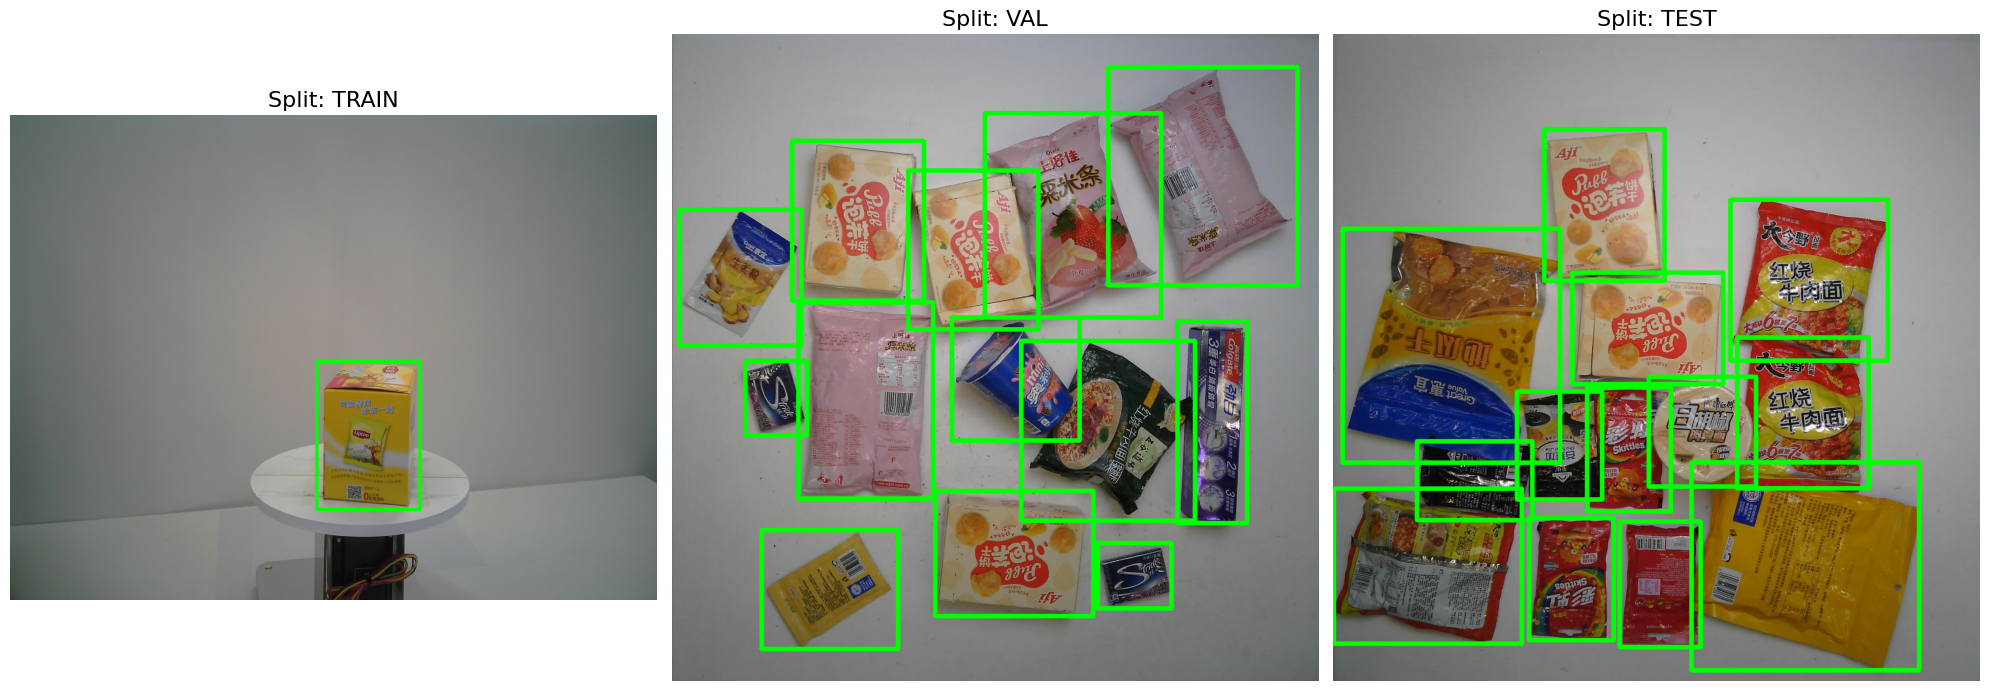

In [154]:
import matplotlib.pyplot as plt
import cv2
import os
import json
import random

# Define the figure size for the entire row of 3 images
plt.figure(figsize=(20, 10))

for i, split in enumerate(splits):
    # 1. Access paths for the current split (train, val, or test)
    ann_path = data_map[split]["annotations"]
    img_dir = data_map[split]["images"]

    # 2. Load the JSON file for this specific split
    with open(ann_path, 'r') as f:
        data = json.load(f)
    
    # 3. Pick a random image entry from the JSON metadata
    sample_img_info = random.choice(data['images'])
    img_id = sample_img_info['id']
    file_name = sample_img_info['file_name']
    
    # 4. Load the actual image file from the directory
    full_img_path = os.path.join(img_dir, file_name)
    image = cv2.imread(full_img_path)
    
    # Safety check: if image path is wrong, skip to the next split
    if image is None:
        print(f"Skipping: File not found at {full_img_path}")
        continue
        
    # Convert BGR (OpenCV default) to RGB (Matplotlib default)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 5. Extract ONLY the annotations belonging to this specific image ID
    # This is the "Filter" step you were missing
    active_anns = [ann for ann in data['annotations'] if ann['image_id'] == img_id]

    # 6. Draw bounding boxes on the image
    for ann in active_anns:
        # COCO format is [x_min, y_min, width, height]
        x, y, w, h = ann['bbox']
        
        # Draw rectangle: (image, start_point, end_point, color, thickness)
        cv2.rectangle(image, (int(x), int(y)), (int(x+w), int(y+h)), (0, 255, 0), 12)

    # 7. Arrange in subplots (1 row, 3 columns, index i+1)
    plt.subplot(1, 3, i + 1)
    plt.imshow(image) # Display the original image with boxes drawn on it
    plt.title(f"Split: {split.upper()}", fontsize=16)
    
    # Add info labels under each image
    plt.xlabel(f"ID: {img_id}\nFile: {file_name}\nObjects: {len(active_anns)}", fontsize=10)
    plt.axis('off') # Hide the X/Y coordinate numbers for a cleaner look
    
    # Free up memory by deleting the large JSON object before the next iteration
    del data 

# Final layout adjustment and rendering
plt.tight_layout()
plt.show()